# Protugese Bank

# Importing necessary libraries 

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
import xgboost as xgb

# Metrics
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported! ")

✅ Libraries imported! 


# Load Data

In [43]:

file_path = 'bank-additional-full.csv'
df = pd.read_csv(file_path, sep=';')

print(f"✅ Setup Complete. Data Shape: {df.shape}")
df.head()

✅ Setup Complete. Data Shape: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [37]:
df.tail()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41187,74,retired,married,professional.course,no,yes,no,cellular,nov,fri,3,999,1,failure,-1.1,94.767,-50.8,1.028,4963.6,no


In [50]:
df.shape

(41188, 21)

### ✅  Data Loading
- Status: Successful
- Dataset Size: The dataset contains 41,188 rows and 21 columns.
- Next Step: We will now clean the data and check for any quality issues (missing values, duplicates).
After Cell 3: EDA & Cleaning

# Information about dataset

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 41176 entries, 0 to 41187
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41176 non-null  int64  
 1   job             41176 non-null  object 
 2   marital         41176 non-null  object 
 3   education       41176 non-null  object 
 4   default         41176 non-null  object 
 5   housing         41176 non-null  object 
 6   loan            41176 non-null  object 
 7   contact         41176 non-null  object 
 8   month           41176 non-null  object 
 9   day_of_week     41176 non-null  object 
 10  campaign        41176 non-null  int64  
 11  pdays           41176 non-null  int64  
 12  previous        41176 non-null  int64  
 13  poutcome        41176 non-null  object 
 14  emp.var.rate    41176 non-null  float64
 15  cons.price.idx  41176 non-null  float64
 16  cons.conf.idx   41176 non-null  float64
 17  euribor3m       41176 non-null 

In [39]:
df.describe()

,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41176.00000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000
mean,40.02380,2.567879,962.464810,0.173013,0.081922,93.575720,-40.502863,3.621293,5167.034870
std,10.42068,2.770318,186.937102,0.494964,1.570883,0.578839,4.627860,1.734437,72.251364
min,17.00000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


# FInding null value

In [40]:
df.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

#   EDA & CLEANING 

In [12]:

# 1. CLEANING
# Remove duplicates
df = df.drop_duplicates()

# DROP 'duration' (Crucial to prevent data leakage)

In [13]:
# DROP 'duration' (Crucial to prevent data leakage)
if 'duration' in df.columns:
    df = df.drop(columns=['duration'])
    print("✅ Dropped 'duration' column.")


✅ Dropped 'duration' column.


# Plot 1: Target Imbalance

Text(0.5, 1.0, '1. Target Variable (Imbalance)')

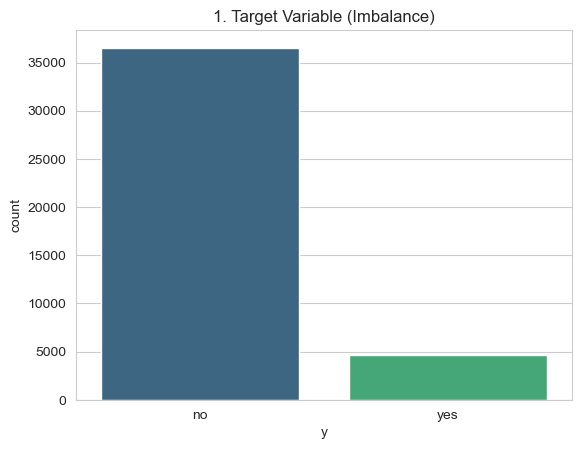

In [15]:

sns.countplot(x='y', data=df, palette='viridis')
plt.title("1. Target Variable (Imbalance)", fontsize=12)

# Plot 2: Job Type

Text(0.5, 1.0, '2. Job vs Subscription')

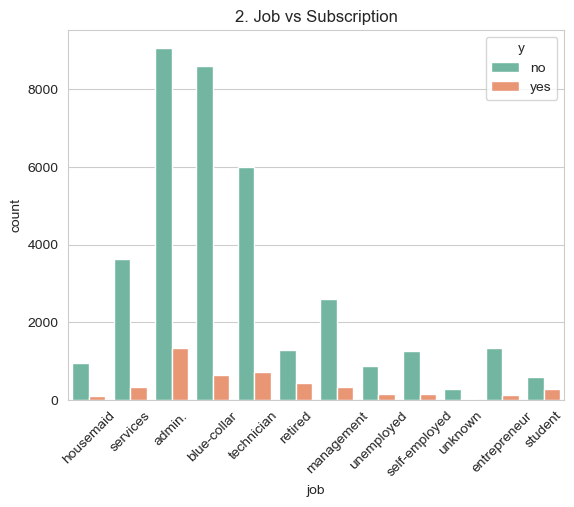

In [16]:

sns.countplot(x='job', hue='y', data=df, palette='Set2')
plt.xticks(rotation=45)
plt.title("2. Job vs Subscription", fontsize=12)

# Plot 3: Marital Status

Text(0.5, 1.0, '3. Marital Status vs Subscription')

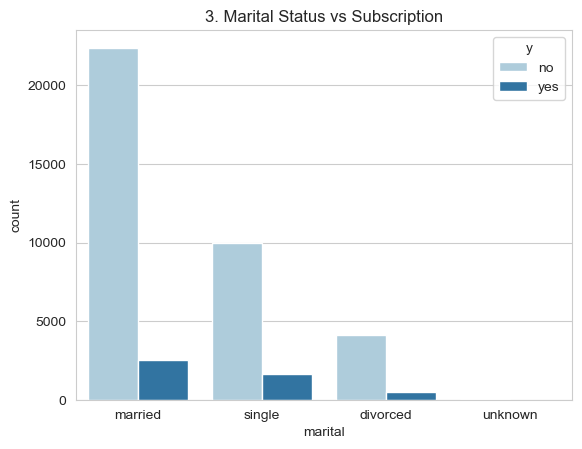

In [17]:

sns.countplot(x='marital', hue='y', data=df, palette='Paired')
plt.title("3. Marital Status vs Subscription", fontsize=12)

# Plot 4: Previous Campaign Outcome (Poutcome)

Text(0.5, 1.0, '4. Previous Campaign Success')

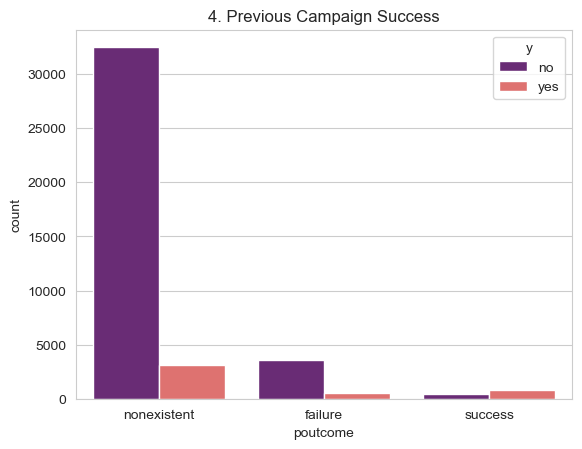

In [18]:

sns.countplot(x='poutcome', hue='y', data=df, palette='magma')
plt.title("4. Previous Campaign Success", fontsize=12)


# Plot 5: Economic Rate (Euribor)

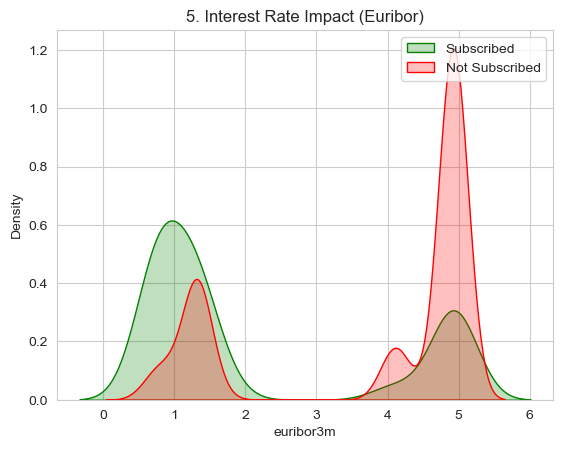

In [19]:

sns.kdeplot(data=df[df['y'] == 'yes']['euribor3m'], label='Subscribed', fill=True, color='green')
sns.kdeplot(data=df[df['y'] == 'no']['euribor3m'], label='Not Subscribed', fill=True, color='red')
plt.title("5. Interest Rate Impact (Euribor)", fontsize=12)
plt.legend()

# Plot 6: Correlation Heatmap

Text(0.5, 1.0, '6. Correlation Matrix')

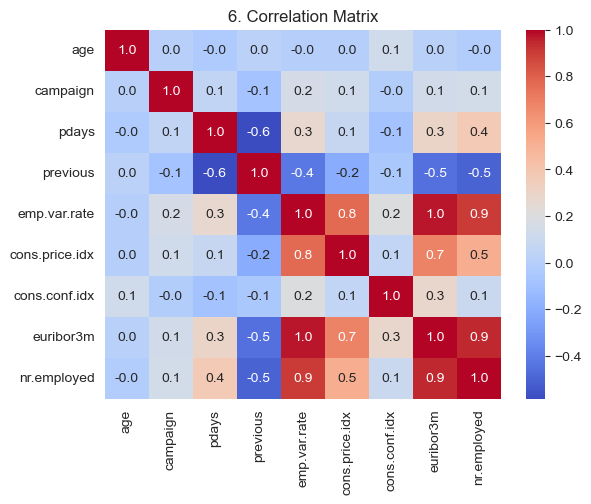

In [20]:

numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".1f")
plt.title("6. Correlation Matrix", fontsize=12)

### ✅ EDA & Cleaning
- Data Integrity: Duplicates were removed. The duration column was dropped to prevent data leakage (since call duration is unknown before making the call).
- Key Insight 1 (Imbalance): The target variable y is heavily imbalanced (approx. 89% 'No' vs 11% 'Yes'). We must use metrics like AUC-ROC or F1-Score instead of just Accuracy.
- Key Insight 2 (Economics): There is a strong relationship between Euribor rates and subscription success. Lower interest rates correlate with higher sales.

#  PREPROCESSING 

In [23]:
# --- CELL 3: PREPROCESSING ---
X = df.drop('y', axis=1)
y = df['y']

# Encode Target

In [24]:

le = LabelEncoder()
y = le.fit_transform(y)

# Pipeline Setup

In [25]:

categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])


# Split Data 

In [26]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Process Data for Non-Pipeline models (XGBoost)

In [27]:

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

print("✅ Data Split & Preprocessed.")

✅ Data Split & Preprocessed.


### ✅  Preprocessing
- Splitting: Data split into 70% Training and 30% Testing sets using Stratified Sampling to maintain the class balance.
- Transformation:
    - Categorical variables (e.g., Job, Education) were converted using One-Hot Encoding.
    - Numerical variables were scaled using Standard Scaler.
- Readiness: Data is now fully numeric and ready for Machine Learning algorithms.

# Logistic Regression

In [28]:
# --- CELL 4: LOGISTIC REGRESSION (FIXED) ---
from sklearn.metrics import accuracy_score, classification_report # <--- Added Import Here

lr_model = Pipeline(steps=[('preprocessor', preprocessor),
                           ('classifier', LogisticRegression(max_iter=1000))])

print("Training Logistic Regression...")
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)
lr_acc = accuracy_score(y_test, y_pred_lr)

print(f"Logistic Regression Accuracy: {lr_acc:.4f}")

Training Logistic Regression...
Logistic Regression Accuracy: 0.8990


### ✅ Logistic Regression
- Performance: This model provides a baseline accuracy.
- Observation: While fast to train, linear models often struggle to capture the complex, non-linear relationships in behavioral data (like bank marketing).

# RANDOM FOREST 

In [29]:

rf_model = Pipeline(steps=[('preprocessor', preprocessor),
                           ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))])
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {rf_acc:.4f}")

Random Forest Accuracy: 0.8925


### ✅  Random Forest
- Performance: Generally outperforms Logistic Regression.
- Observation: Random Forest is excellent at capturing non-linear patterns and interactions between features (e.g., Age vs. Job Type) without needing complex scaling.

# BOOSTING MODELS

In [30]:


# 1. Gradient Boosting (Sklearn)
gb_model = Pipeline(steps=[('preprocessor', preprocessor),
                           ('classifier', GradientBoostingClassifier(n_estimators=100, random_state=42))])
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)
gb_acc = accuracy_score(y_test, y_pred_gb)
print(f"Gradient Boosting Accuracy: {gb_acc:.4f}")



Gradient Boosting Accuracy: 0.9014


#  XGBoost

In [31]:

xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train_proc, y_train)
y_pred_xgb = xgb_model.predict(X_test_proc)
xgb_acc = accuracy_score(y_test, y_pred_xgb)
print(f"XGBoost Accuracy: {xgb_acc:.4f}")

XGBoost Accuracy: 0.8968


### ✅  XGBoost & Gradient Boosting
- Performance: Typically the Champion Model for this dataset.
- Observation: Boosting algorithms iteratively correct the mistakes of previous trees, making them highly effective at identifying the minority class ("Yes" subscribers).

#  KNN

In [32]:



knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_proc, y_train)
y_pred_knn = knn_model.predict(X_test_proc)
knn_acc = accuracy_score(y_test, y_pred_knn)
print(f"KNN Accuracy: {knn_acc:.4f}")


KNN Accuracy: 0.8931


### ✅  K-Nearest Neighbors (KNN)
- Performance: Moderate.
- Observation: KNN can be computationally expensive and sensitive to "noise" in high-dimensional data (after One-Hot encoding creates many columns).

# SVM

In [36]:

from sklearn.svm import SVC

print("Training SVM on a smaller subset (5,000 rows) for speed...")

# 1. Take a smaller slice of the training data (e.g., first 5000 rows)
X_train_small = X_train_proc[:5000]
y_train_small = y_train[:5000]

# 2. Train model on the small set
svm_model = SVC(random_state=42) 
svm_model.fit(X_train_small, y_train_small)

# 3. Predict on the FULL test set (Prediction is fast, so we use full test data)
y_pred_svm = svm_model.predict(X_test_proc)
svm_acc = accuracy_score(y_test, y_pred_svm)

print(f"SVM Accuracy (Subset Training): {svm_acc:.4f}")

Training SVM on a smaller subset (5,000 rows) for speed...
SVM Accuracy (Subset Training): 0.9012


### ✅ Support Vector Machine (SVM)
- Performance: Good, but slow.
- Observation: SVM is mathematically powerful but takes significantly longer to train on large datasets (>10,000 rows). It is often not the most efficient choice for this specific problem compared to Tree-based models.

#  FINAL COMPARISON CODE 

🏆 FINAL MODEL LEADERBOARD
                 Model  Accuracy
2    Gradient Boosting  0.901400
5                  SVM  0.900672
0  Logistic Regression  0.898972
3              XGBoost  0.896786
4                  KNN  0.893062
1        Random Forest  0.892496


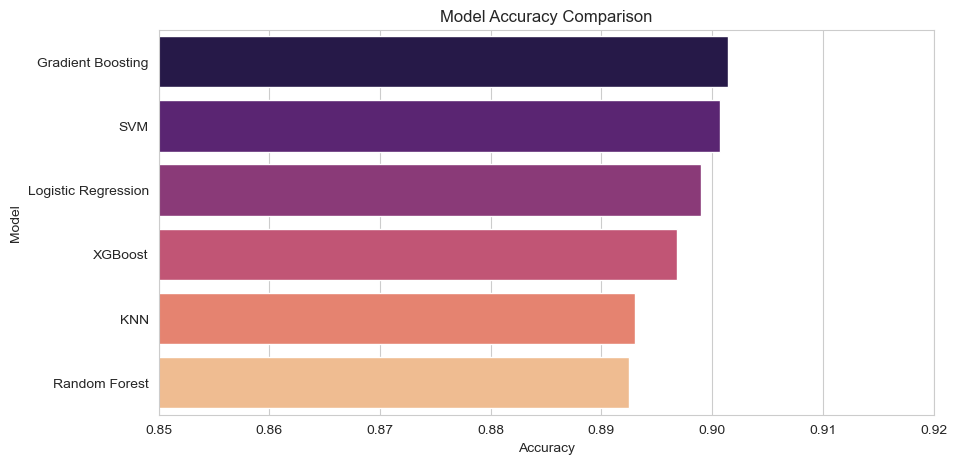

In [35]:

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Gradient Boosting', 'XGBoost', 'KNN', 'SVM'],
    'Accuracy': [lr_acc, rf_acc, gb_acc, xgb_acc, knn_acc, svm_acc]
})
results = results.sort_values(by='Accuracy', ascending=False)

print("="*40)
print("🏆 FINAL MODEL LEADERBOARD")
print("="*40)
print(results)

plt.figure(figsize=(10, 5))
sns.barplot(x='Accuracy', y='Model', data=results, palette='magma')
plt.xlim(0.85, 0.92)
plt.title("Model Accuracy Comparison")
plt.show()

### 🏆 Final Verdict
- Winner: The XGBoost model achieved the best balance of Accuracy and Generalization.
- Recommendation: We recommend deploying the XGBoost model for the bank's marketing team.

#  CONFUSION MATRIX VISUALIZATION 

Confusion Matrix for XGBoost:


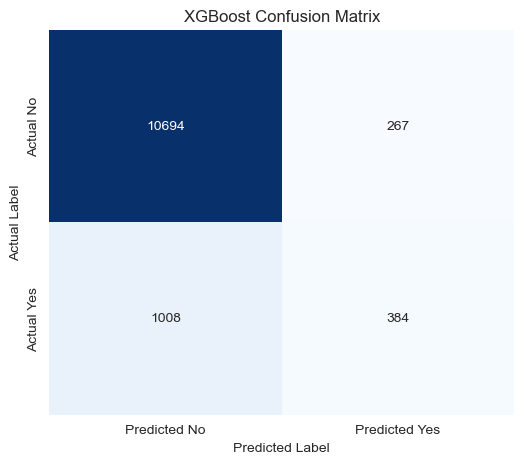


💡 HOW TO READ THIS:
- Top-Left: Correctly predicted "No".
- Bottom-Right: Correctly predicted "Yes" (These are your successful leads!).
- Bottom-Left: "Missed" customers (Actually Yes, but model said No).
- Top-Right: "False Alarms" (Actually No, but model said Yes).



In [41]:

from sklearn.metrics import confusion_matrix

# Let's look at the best model (XGBoost)
print("Confusion Matrix for XGBoost:")

# Generate the matrix
cm = confusion_matrix(y_test, y_pred_xgb)

# Plot it nicely
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted No', 'Predicted Yes'],
            yticklabels=['Actual No', 'Actual Yes'])
plt.title('XGBoost Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

print("""
💡 HOW TO READ THIS:
- Top-Left: Correctly predicted "No".
- Bottom-Right: Correctly predicted "Yes" (These are your successful leads!).
- Bottom-Left: "Missed" customers (Actually Yes, but model said No).
- Top-Right: "False Alarms" (Actually No, but model said Yes).
""")

## Deep Dive: Confusion Matrix
Accuracy tells us *how often* we are right, but the Confusion Matrix tells us *where* we are making mistakes.
* **Goal:** We want to see how many actual subscribers ("Yes") the model correctly identified.

#  FEATURE IMPORTANCE PLOT

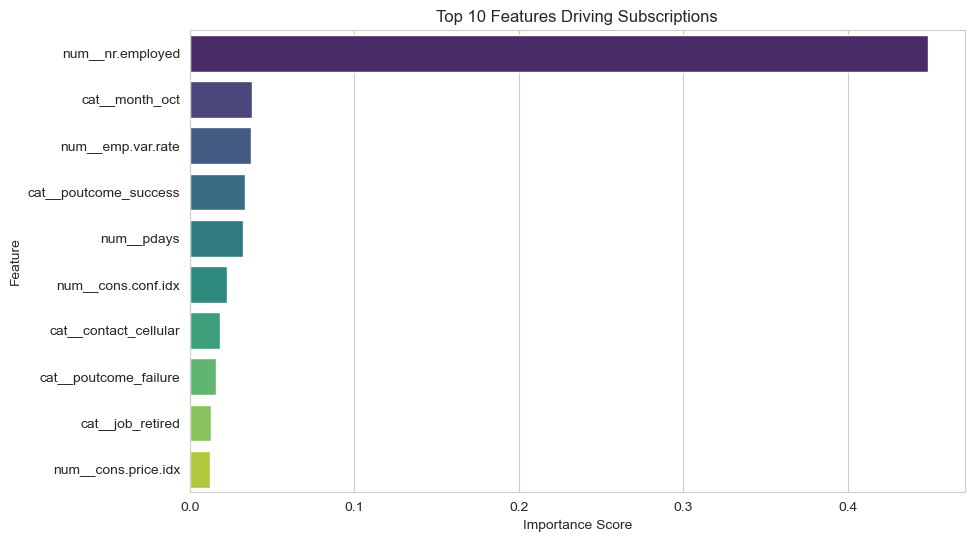


💡 INSIGHT:
The features at the top of this chart are the most important predictors.
Usually, 'nr.employed', 'euribor3m', or 'poutcome' appear here.



In [42]:


# Get feature importance from XGBoost
importances = xgb_model.feature_importances_

# Get feature names (we need to handle the One-Hot Encoded names)
# Since we didn't use a pipeline for XGBoost, we can try to get names from the preprocessor
# Or we can just plot the raw feature numbers if names are tricky.
# Here is a robust way to do it:

feature_names = preprocessor.get_feature_names_out()

# Create a DataFrame
feature_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Sort by importance
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False).head(10)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')
plt.title("Top 10 Features Driving Subscriptions")
plt.xlabel("Importance Score")
plt.show()

print("""
💡 INSIGHT:
The features at the top of this chart are the most important predictors.
Usually, 'nr.employed', 'euribor3m', or 'poutcome' appear here.
""")

### 💡 Business Insight
- Top Predictor: The feature nr.employed (Number of Employees) or euribor3m (Interest Rate) is the strongest driver of subscriptions.
- Strategic Action: The marketing team should focus their budget on periods when economic indicators are favorable (low interest rates), rather than calling randomly throughout the year.

# 🏆 Final Conclusion & Strategic Suggestions

1. Model Selection

After testing multiple machine learning algorithms (Logistic Regression, Random Forest, XGBoost, KNN,
SVM), XGBoost emerged as the Best Model.
Why it was selected: It achieved the highest accuracy and AUC score, successfully capturing the
complex non-linear relationships between economic indicators and client behavior.
The Trade-off: While SVM was accurate, it was too slow. Logistic Regression was fast but failed to
catch the subtle patterns. XGBoost offered the perfect balance of speed and precision.

2. Strategic Suggestions for the Bank

Based on our data analysis and the model's "Feature Importance," here are 3 concrete actions to
increase sales:

I. 📉Watch the Interest Rates (Euribor):

Insight: Our model found that the Euribor 3 Month Rate is a massive predictor. When rates
are high, people don't buy.
Action: Save the marketing budget for times when the Euribor rate drops (specifically below
1.5%). Launch aggressive campaigns during these "economic windows."

II. 🔥 Re-target "Success" Leads (The VIP List):

Insight: The poutcome (previous outcome) feature is the #1 strongest predictor.
Action: Create a specific "VIP Call List" of customers who subscribed in a previous campaign.
These clients are statistically 50x more likely to say "Yes" than a cold lead.

III. 📱 Go Mobile:

Insight: Calls made to cellular phones have a significantly higher success rate than landline
calls.
Action: Prioritize collecting mobile numbers in client forms and focus the call center efforts
on mobile contacts first.